In [11]:
import os
from google.colab import userdata
os.environ["OPENAI_API_KEY"] = userdata.get('OPENAI_API_KEY')

In [10]:
!pip install -q openai langchain-openai langchain-community faiss-cpu python-dotenv gradio

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 88.5/88.5 kB 6.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 40.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.8/23.8 MB 49.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 50.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.9/64.9 kB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.0/51.0 kB 4.3 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires requests==2.32.4, but you have requests 2.33.1 which is incompatible.


In [16]:
import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from typing import List, Dict, Tuple, Any
#from dotenv import load_dotenv
from langchain_openai import OpenAIEmbeddings, ChatOpenAI
from langchain_community.vectorstores import FAISS
from langchain_core.documents import Document
from langchain_core.messages import HumanMessage, SystemMessage, AIMessage
#load_dotenv()
LLM_MODEL = "gpt-4o-mini"
EMBEDDING_MODEL = "text-embedding-3-small"
llm = ChatOpenAI(model=LLM_MODEL)
embeddings_model = OpenAIEmbeddings(model=EMBEDDING_MODEL)

In [13]:
import os
import math
import numpy as np
import warnings
warnings.filterwarnings('ignore')
from collections import Counter
from langchain_openai import OpenAIEmbeddings, ChatOpenAI
#from dotenv import load_dotenv
#load_dotenv()
embeddings = OpenAIEmbeddings(model="text-embedding-3-small")
documents = [
    "Python은 데이터 과학과 머신러닝에 널리 사용되는 프로그래밍 언어입니다.",
    "자연어 처리(NLP)는 컴퓨터가 인간의 언어를 이해하고 생성하는 기술입니다.",
    "벡터 데이터베이스는 고차원 벡터를 효율적으로 저장하고 검색하는 시스템입니다.",
    "GPT-4는 OpenAI가 개발한 대규모 언어 모델로 다양한 작업을 수행합니다.",
    "RAG(검색 증강 생성)는 외부 지식을 활용하여 LLM 응답을 개선합니다.",
    "FastAPI는 Python으로 빠른 웹 API를 구축하기 위한 프레임워크입니다.",
    "트랜스포머 아키텍처는 어텐션 메커니즘을 활용한 딥러닝 모델 구조입니다.",
    "FAISS는 Facebook AI가 개발한 효율적인 유사도 검색 라이브러리입니다.",
    "프롬프트 엔지니어링은 LLM에 효과적인 입력을 설계하는 기술입니다.",
    "임베딩은 텍스트를 수치 벡터로 변환하여 의미적 유사성을 측정할 수 있게 합니다.",
]

# 하이브리드 검색

In [ ]:
# 하이브리드 검색?


In [51]:
doc_embeddings = embeddings.embed_documents(documents)
len(doc_embeddings), len(doc_embeddings[0])

(10, 1536)

In [ ]:
doc_embeddings.shape # 얘는 shape를 찍으면 안나옴, 아래 SentenceTransformer는 나옴

AttributeError: 'list' object has no attribute 'shape'

In [ ]:
np.array(doc_embeddings) # 넘파이로 넣으면 나옴

array([[ 0.00657654,  0.03048706, -0.02264404, ..., -0.05459595,
        -0.01644897,  0.00080776],
       [ 0.0022068 ,  0.00142765, -0.01383209, ..., -0.02345276,
         0.01748657, -0.01129913],
       [-0.02809143, -0.00685883, -0.01005554, ..., -0.01413727,
         0.04055786, -0.01039124],
       ...,
       [-0.02554321, -0.00035667, -0.01853943, ...,  0.03927612,
        -0.04629517, -0.01712036],
       [ 0.0340271 ,  0.0463562 , -0.02189636, ...,  0.00666428,
         0.02731323, -0.01059723],
       [-0.01885986,  0.04116821,  0.00100899, ..., -0.01399994,
         0.00841522,  0.00331116]])

In [ ]:
!pip install sentence-transformers

In [49]:
from sentence_transformers import SentenceTransformer

In [50]:
embedding_model = SentenceTransformer('all-MiniLM-L6-v2')

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

In [47]:
embedding = embedding_model.encode(documents) # document를 임베딩한 결과를 embedding 변수에 저장함

NameError: name 'embedding_model' is not defined

In [ ]:
embedding.shape

(10, 384)

In [ ]:
embedding

array([[-0.02818314,  0.02315174, -0.01332175, ...,  0.09440272,
         0.0626434 , -0.00686622],
       [ 0.00433088,  0.02231268,  0.0685296 , ...,  0.06287046,
         0.03236048,  0.01451781],
       [ 0.04224592,  0.06530678,  0.02390079, ...,  0.01747436,
        -0.08692617,  0.02379493],
       ...,
       [-0.03313584,  0.02055408,  0.00575811, ...,  0.07556443,
        -0.08282115, -0.06177337],
       [ 0.0905104 , -0.00739949,  0.04021925, ..., -0.00768862,
        -0.11420649, -0.01269382],
       [ 0.01094466,  0.08185511,  0.03489945, ...,  0.01663296,
        -0.08264516,  0.02735938]], dtype=float32)

In [ ]:
# 파이썬 뭔가요? -> 파이썬은 ~~~~
# 약품명 NeqHp 등? 키워드 검색이 유리

In [43]:
def keyword_search(query, docs, top_k=3): # 질문과 문서를 입력받아, top_k에 해당되는 문서를 리턴
  query_tokens = set(query.lower().split()) # 모두 소문자로 변환, set은 중복된 값 제거
  scores = []
  for i, doc in enumerate(docs):
    doc_tokens = set(doc.lower().split())
    overlap = len(query_tokens & doc_tokens)# 겹치는것
    scores.append((i,overlap))

    # scores = [(0, 3), (1, 2) ..]
  scores.sort(key=lambda x:x[1], reverse=True)
  return scores[:top_k]

In [44]:
results = keyword_search("Python 프로그래밍 언어", documents)
print(results)
for idx, scores in results:
  print(f"[{idx}] overlap = {scores} | {documents[idx][:30]}")

[(0, 1), (3, 1), (1, 0)]
[0] overlap = 1 | Python은 데이터 과학과 머신러닝에 널리 사용되는 
[3] overlap = 1 | GPT-4는 OpenAI가 개발한 대규모 언어 모델로 
[1] overlap = 0 | 자연어 처리(NLP)는 컴퓨터가 인간의 언어를 이해하고


In [ ]:
results

[(0, 1), (3, 1), (1, 0)]

In [52]:
def vector_search(query, docs, doc_embs, top_k = 3):
  q_emb = np.array(embeddings.embed_query(query))
  similarities = np.dot(doc_embs, q_emb) / (np.linalg.norm(doc_embs, axis=1)* np.linalg.norm(q_emb) ) #코사인 유사도 공식을 넘파이로 구현한것임
  top_indices = similarities.argsort()[::-1][:top_k] # 유사도기반 순서로 정렬한 다음 해당 인덱스를 뽑음?

  return [(i, similarities[i]) for i in top_indices]

results = vector_search("Python 프로그래밍 언어", documents, np.array(doc_embeddings), top_k = 3)

In [ ]:
results
for idx, scores in results:
  print(f"[{idx}] similarity = {scores} | {documents[idx][:30]}")

[0] similarity = 0.5528473798288958 | Python은 데이터 과학과 머신러닝에 널리 사용되는 
[1] similarity = 0.37179235223584567 | 자연어 처리(NLP)는 컴퓨터가 인간의 언어를 이해하고
[3] similarity = 0.360448283229595 | GPT-4는 OpenAI가 개발한 대규모 언어 모델로 


In [ ]:
a = [1,2,3,4,5]
# a.argsort() # argsort?? sorting을 하면 5,4,3,2,1로 나올건데, argsort는 인덱스대로 sorting한다는것
a[::-1][:3]

[5, 4, 3]

In [ ]:
# 만약 한글을 키워드 search로 쓴다고 하면 전처리가 필요함 (파이썬 -> Python 등.. 파이썬은(는) -> 파이썬) 형태소 처리 등

## FAISS 이용

In [70]:
results = vector_search('FAISS', documents, np.array(doc_embeddings), top_k=3)

In [ ]:

for idx, scores in results:
  print(f"[{idx}] similarity = {scores} | {documents[idx][:30]}")

[7] similarity = 0.5278809597501696 | FAISS는 Facebook AI가 개발한 효율적인 유
[4] similarity = 0.19233440678444033 | RAG(검색 증강 생성)는 외부 지식을 활용하여 LLM
[5] similarity = 0.09642334637561256 | FastAPI는 Python으로 빠른 웹 API를 구축


⭐ 키워드 search의 경우는 새로운 정보/키워드 또는 잘 알려지지 않은 용어, 이름 등을 검색하는데 유리. (아직 인공지능이 학습하지 못한 케이스 등)

In [ ]:
def overlap_rate(keyword_results, vector_results):

  # overlap
  # union
  # overlap / union
  # 겹치는 비율 구하기

In [ ]:
def overlap_rate(keyword_results, vector_results):
    keyword_ids = set([i for i, score in keyword_results])
    print(f"keyword_ids: {keyword_ids}")
    vector_ids  = set([i for i, score in vector_results])
    print(f"vector_ids: {vector_ids}")

    overlap = keyword_ids & vector_ids # 교집합
    union = keyword_ids | vector_ids # 합집합

    return len(overlap) / len(union) if union else 0.0

In [ ]:
results_vec = vector_search('Python 프로그래밍 언어', documents, np.array(doc_embeddings), top_k=3)
results_key = keyword_search("Python 프로그래밍 언어", documents)

In [ ]:
overlap_rate(results_key,results_vec)

keyword_ids: {0, 1, 3}
vector_ids: {np.int64(0), np.int64(1), np.int64(3)}


1.0

## 하이브리드 서치 구현

In [ ]:
def simple_hybrid(query, docs, doc_embs, top_k = 3):
  kw =  keyword_search(query, documents, top_k = len(docs))
  vec = vector_search(query, docs, np.array(doc_embs), top_k = len(docs))

  kw_scores = {idx : score for idx, score in kw}
  vec_scores = {idx : score for idx, score in vec}

  # kw : (0th, 100점) , (1st, 50점), (2nd, 30) ,.... (100, 0점)
  # vec : (0, 1), (1st, 0.5 ), ...
  # 두개 스케일 다름.
  # len(doc) -> 다 보겠다.

  # 스케일 다르므로 정규화 수행
  kw_max = max(kw_scores.values()) or 1 # max가 0일 수 있음.. 따라서 or 1 기입
  vec_max = max(vec_scores.values()) or 1

  combined = {}

  for idx in range(len(docs)):
    kw_score = kw_scores.get(idx, 0) / kw_max
    vec_score = vec_scores.get(idx, 0) / vec_max

    combined[idx] = kw_score + vec_score # -> 정규화된 두 값을 더해줌, 더해준 스코어를 기반으로 ranked, 순서를 매김

  ranked = sorted(combined.items(), key = lambda x:x[1], reverse = True)
  return ranked[:top_k]


In [ ]:
for query in ['Python 프로그래밍 언어', '딥러닝 모델 구조', 'FAISS']:
  results = simple_hybrid(query, documents, np.array(doc_embeddings), top_k =3 )
  #print(results)

  for idx, score in results:
    print(f"[{idx}] {score} | {documents[idx][:30]}")

  print("="*100)

[0] 2.0 | Python은 데이터 과학과 머신러닝에 널리 사용되는 
[3] 1.6519851524685754 | GPT-4는 OpenAI가 개발한 대규모 언어 모델로 
[1] 0.672504502690985 | 자연어 처리(NLP)는 컴퓨터가 인간의 언어를 이해하고
[6] 2.0 | 트랜스포머 아키텍처는 어텐션 메커니즘을 활용한 딥러닝 
[3] 0.4905194025659972 | GPT-4는 OpenAI가 개발한 대규모 언어 모델로 
[0] 0.4187993403594779 | Python은 데이터 과학과 머신러닝에 널리 사용되는 
[7] 1.0 | FAISS는 Facebook AI가 개발한 효율적인 유
[4] 0.3643507332537184 | RAG(검색 증강 생성)는 외부 지식을 활용하여 LLM
[5] 0.18265533898635625 | FastAPI는 Python으로 빠른 웹 API를 구축


# TF-IDF
단어 중요도를 숫자로 표현
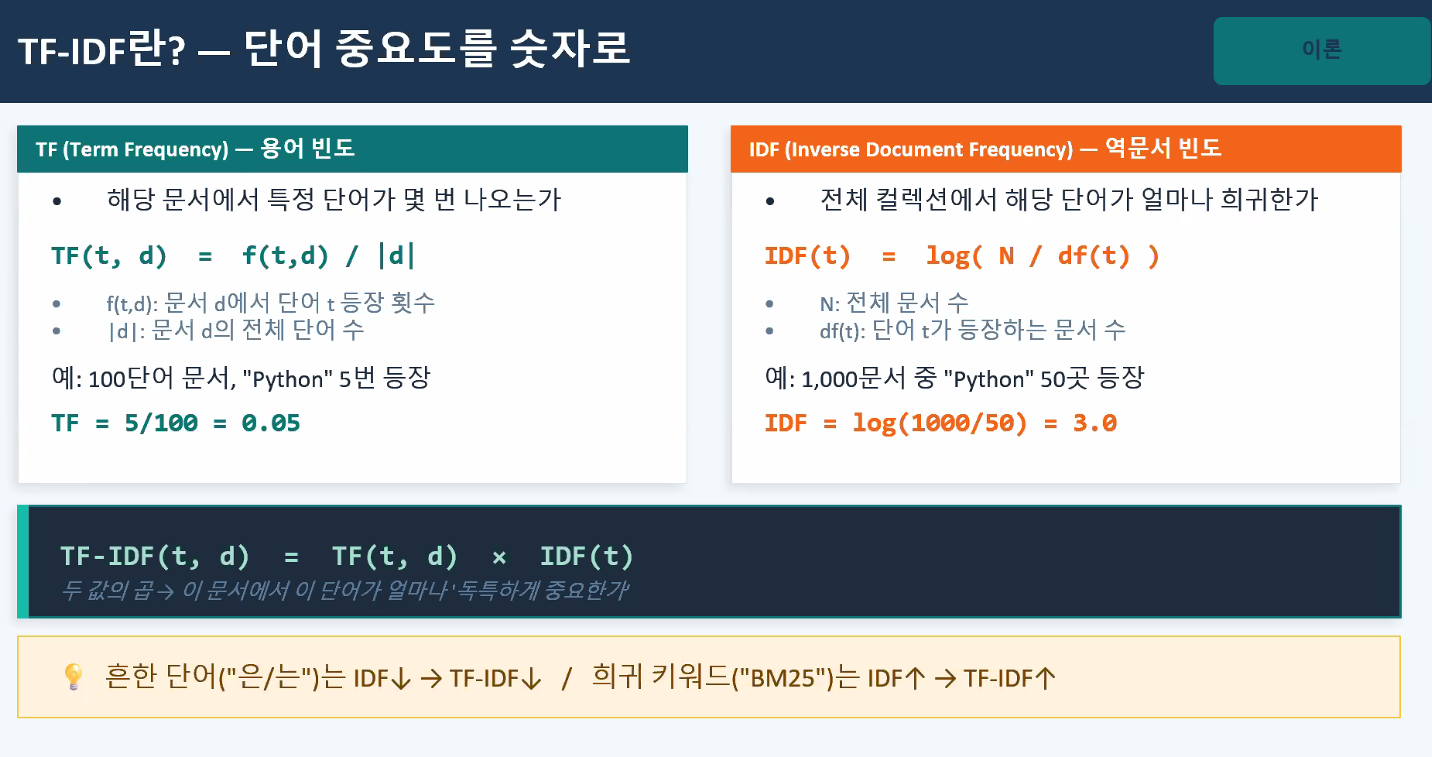

- TF로 'a', 'an', 'the' 등을 쓰면 엄청 빈도가 높을것임
- IDF는 해당 단어가 등장하는 문서 수로 전체 문서수를 나눠주는것

- TF-IDF는 두개의 곱임 -> TF * IDF

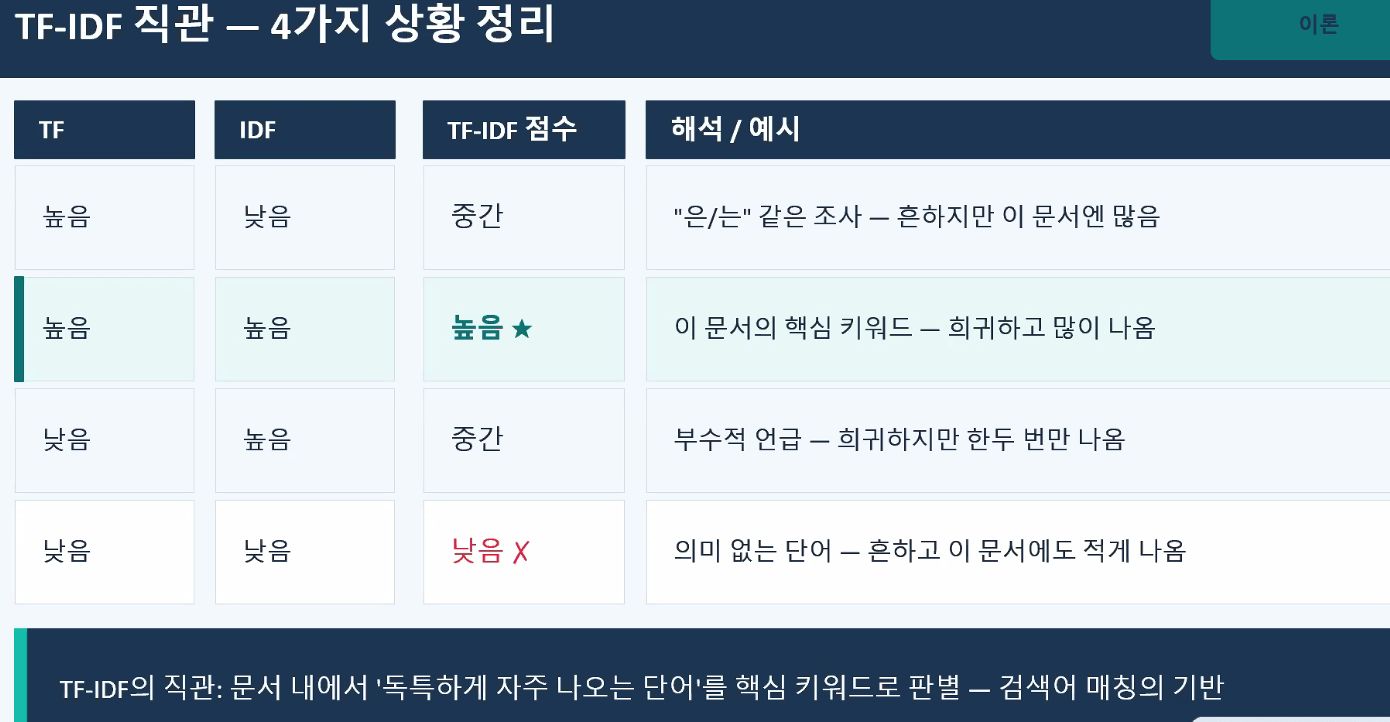

In [ ]:
# TF는 포화도가 있음.. 특정 단어가 5번 나온 문서나 50번 나온 문서나 둘다 관련도는 있다고 판단해야함

# 문서 길이 보정이 불충분함. 1000개 단어 문서에서 특정 단어가 5번 나온것이나, 100개 단어 문서에서 5번 나온거나 의미는 완전 다름!
# 하지만 TF는 같다고 취급함

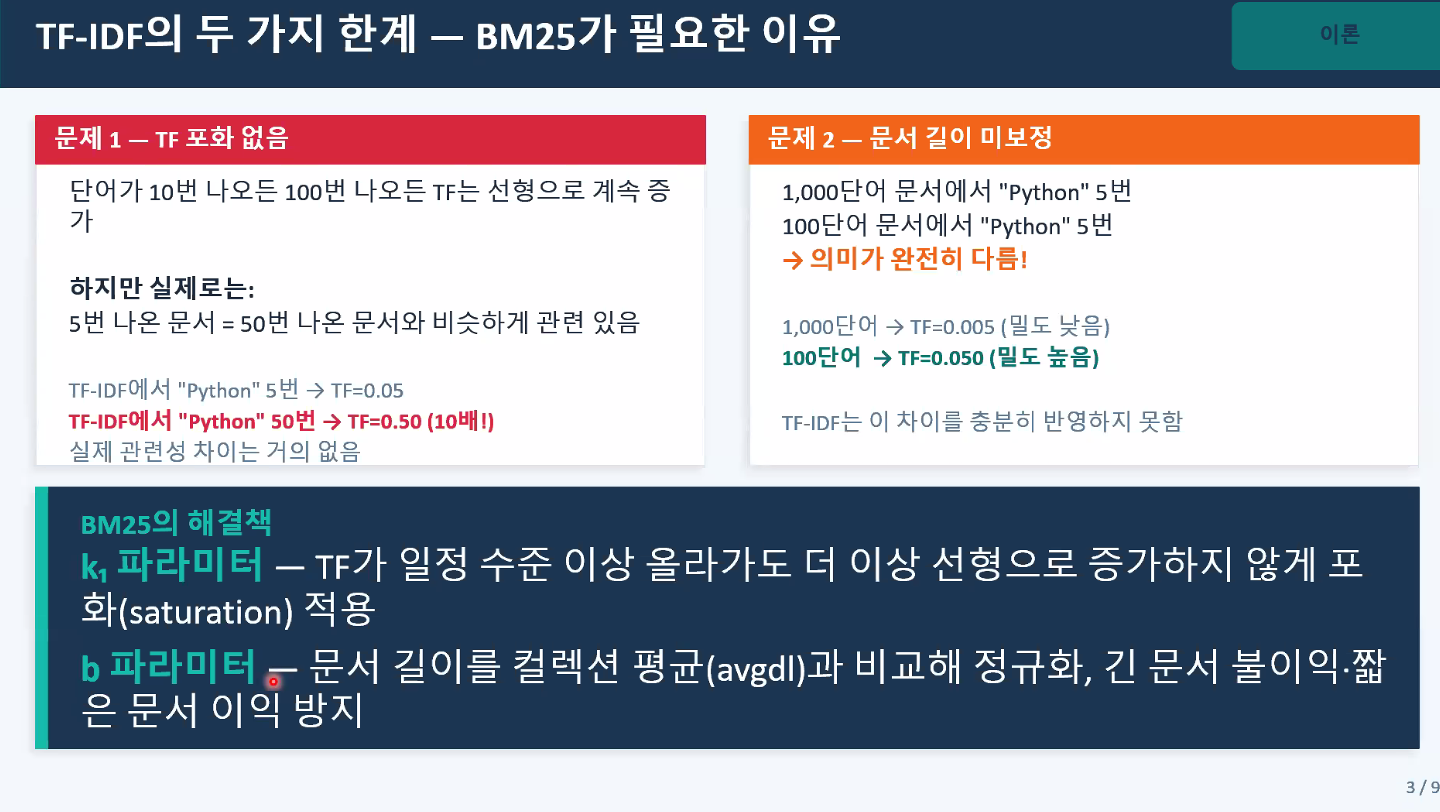

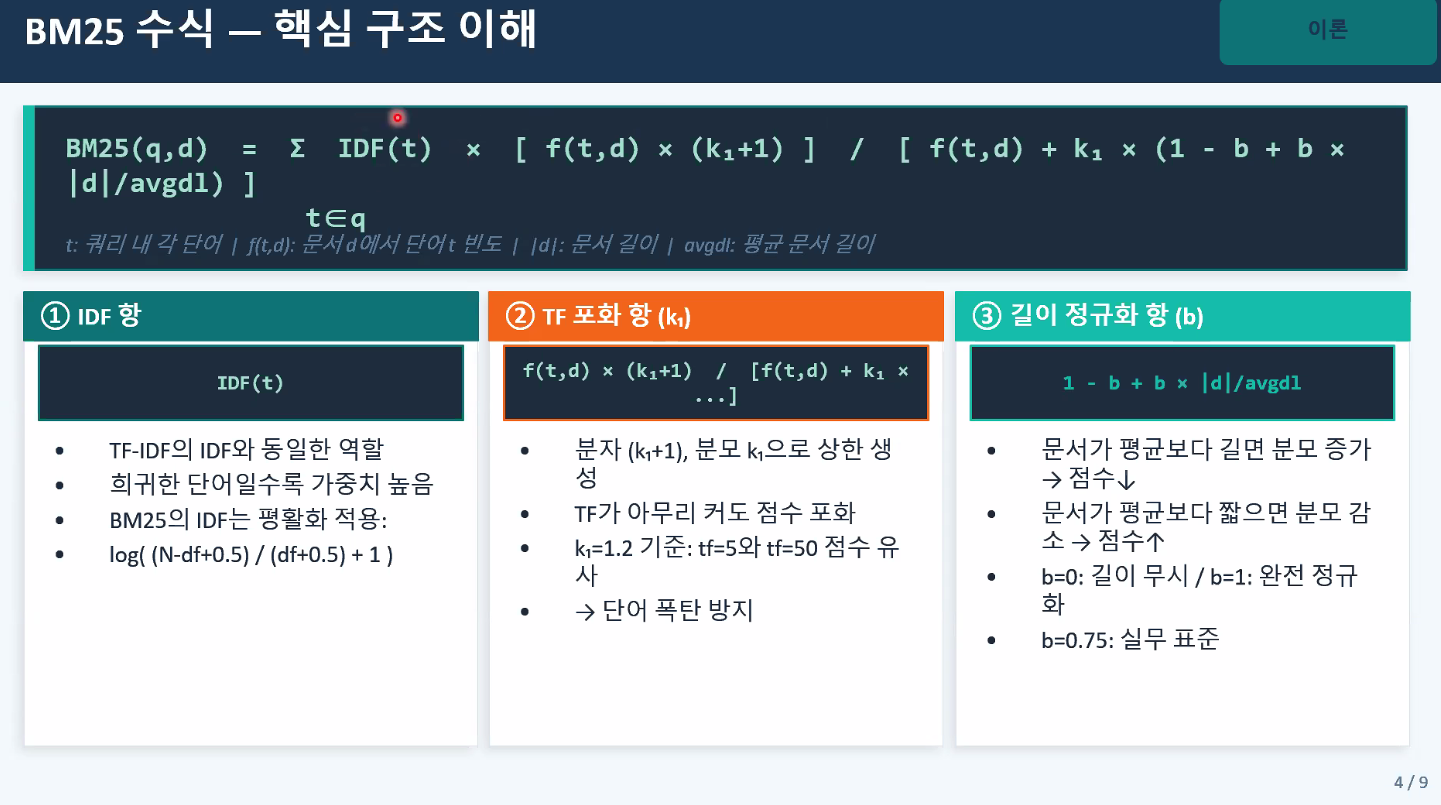

In [ ]:
# 2번항: saturation 항임. f가 아무리 커져서 무한대로 간다고 해도, 특정 값으로 수렴하도록 함('k_1 + 1'로 수렴 == 거의 maximum)
# 3번항: 길이 정규화 항, 문서의 길이를 평균 길이로 나눠줌 (평균보다 짧은지, 긴지 등의 비율값)
  # 평균 문서 길이가 길어지면  => 3번항 전체값이 커짐 => 분모가 커짐 => 점수가 낮아짐
  # 평균 문서 길이가 짧아지면 => 3번항 값이 낮아짐 => BM25 분모가 작아짐 => 점수가 커짐
  # b도 k도 하이퍼 파라미터임.. 시스템의 목적에 따라 실험 하면서 조정하면됨

### 코드 구현 부분

In [ ]:
# TF는 f(t,d) / |d|,, (f(t,d): document에 나온 t의 개수, |d| : d의 길이)
# IDF: log(N / (t가 등장한 문서의 개수)) (N: 전체 문서 수)

In [24]:
class TFIDF:
  def __init__(self, documents):
    self.docs = documents
    self.tokenized = [doc.lower().split() for doc in documents]
    self.N = len(documents)
    self.df = {}
    for tokens in self.tokenized: # 토크나이저로 구별한 토큰마다,,
      for t in set(tokens): # 중복 제거한 토큰에 대해 각 토큰마다
        self.df[t] = self.df.get(t,0) + 1 # 어떤 단어를 만날때마다 1 더함

  def tf(self, term, doc_tokens):
    return doc_tokens.count(term) / len(doc_tokens)

  def idf(self, term):
    return math.log(self.N / self.df.get(term, 1)) # 1은 오류 방지

  def score(self, query, doc_idx):
    tokens = self.tokenized[doc_idx]
    return sum(self.tf(t, tokens)* self.idf(t) for t in query.lower().split())

  def search(self, query, top_k = 3):
    scores = [(i, self.score(query, i)) for i in range(self.N)]  # N개는 document의 길이임, score 함수를 구함
    return sorted(scores, key=lambda x: x[1], reverse=True)[:top_k]


In [25]:
tfidf = TFIDF(documents)
for idx, score in tfidf.search('Python 프로그래밍'):
  print(f"[{idx}] {score} | {documents[idx][:30]}")

[0] 0.28782313662425574 | Python은 데이터 과학과 머신러닝에 널리 사용되는 
[1] 0.0 | 자연어 처리(NLP)는 컴퓨터가 인간의 언어를 이해하고
[2] 0.0 | 벡터 데이터베이스는 고차원 벡터를 효율적으로 저장하고 


In [3]:
class BM25: # k_1과 b 두개의 하이퍼파라미터 있음.
  def __init__(self, documents, k1=1.5, b=0.75):
    self.k1, self.b = k1, b
    self.docs = documents
    self.tokenized = [doc.lower().split() for doc in documents]
    self.N = len(documents)
    self.avgdl = sum(len(d) for d in self.tokenized) / self.N
    self.df = {}
    for tokens in self.tokenized:
      for t in set(tokens):
        self.df[t] = self.df.get(t, 0) + 1

  def idf(self, term):
    df = self.df.get(term, 0)
    return math.log((self.N - df + 0.5) / (df + 0.5) + 1)

  def score(self, query, doc_idx):
    tokens = self.tokenized[doc_idx]
    dl = len(tokens)
    tf_counter = Counter(tokens)
    total = 0.0
    for t in query.lower().split():
      tf = tf_counter.get(t,0)
      numerator  = tf * (self.k1 + 1)
      denominator = tf + (self.k1 * (1-self.b + self.b * dl/self.avgdl))

      total += self.idf(t) * numerator / denominator

    return total

  def search(self, query, top_k = 3):
    scores = [(i, self.score(query, i)) for i in range(self.N)]
    return sorted(scores, key = lambda x:x[1], reverse =True)[:top_k]



In [19]:
bm25 = BM25(documents)

for idx, score in bm25.search("Python 프로그래밍"):
  print(f"[{idx}] {score} | {documents[idx][:30]}")

[0] 2.0360600223111596 | Python은 데이터 과학과 머신러닝에 널리 사용되는 
[1] 0.0 | 자연어 처리(NLP)는 컴퓨터가 인간의 언어를 이해하고
[2] 0.0 | 벡터 데이터베이스는 고차원 벡터를 효율적으로 저장하고 


In [60]:
from langchain_community.retrievers import BM25Retriever

In [58]:
from langchain_core.documents import Document

In [57]:
pip install rank_bm25

In [61]:
docs_lc = [Document(page_content = d, metadata = {"index": i}) for i, d in enumerate(documents)]

bm25_retriever = BM25Retriever.from_documents(docs_lc)

In [62]:
bm25_retriever.k = 3
results = bm25_retriever.invoke('Python 프로그래밍')
results

[Document(metadata={'index': 0}, page_content='Python은 데이터 과학과 머신러닝에 널리 사용되는 프로그래밍 언어입니다.'),
 Document(metadata={'index': 9}, page_content='임베딩은 텍스트를 수치 벡터로 변환하여 의미적 유사성을 측정할 수 있게 합니다.'),
 Document(metadata={'index': 8}, page_content='프롬프트 엔지니어링은 LLM에 효과적인 입력을 설계하는 기술입니다.')]

In [63]:
# 벡터검색, FAISS

from langchain_community.vectorstores import FAISS

vectorstore = FAISS.from_documents(docs_lc, embeddings)
vector_retriever = vectorstore.as_retriever(search_kwargs = {'k': 3})

In [ ]:
results = vector_retriever.invoke('딥러닝 모델 구조')
results

[Document(id='8a3423e0-21da-4270-a0d8-9bb1ba9f15c3', metadata={'index': 6}, page_content='트랜스포머 아키텍처는 어텐션 메커니즘을 활용한 딥러닝 모델 구조입니다.'),
 Document(id='ac87cb6b-fdc0-453c-8660-3a9a16c42f47', metadata={'index': 3}, page_content='GPT-4는 OpenAI가 개발한 대규모 언어 모델로 다양한 작업을 수행합니다.'),
 Document(id='5fa0e850-51c4-469a-9f94-3e8d324fc874', metadata={'index': 0}, page_content='Python은 데이터 과학과 머신러닝에 널리 사용되는 프로그래밍 언어입니다.')]

In [ ]:
from langchain_classic.retrievers import EnsembleRetriever

In [ ]:
# 앙상블?
# 여러 모델의 예측을 함께 사용하는것
# 다수결 방식이라던가,, 평균?

In [ ]:
ensemble = EnsembleRetriever(
    retrievers = [vector_retriever, bm25_retriever],
    weights = [0.5, 0.5], # 공평하게 반반씩 가중치 줌
)

In [ ]:
results = ensemble.invoke("Python 데이터 과학")
results

[Document(id='5fa0e850-51c4-469a-9f94-3e8d324fc874', metadata={'index': 0}, page_content='Python은 데이터 과학과 머신러닝에 널리 사용되는 프로그래밍 언어입니다.'),
 Document(id='319a0f4a-a991-45a0-8ff2-185b41f6c6af', metadata={'index': 9}, page_content='임베딩은 텍스트를 수치 벡터로 변환하여 의미적 유사성을 측정할 수 있게 합니다.'),
 Document(id='227b1422-cb1a-4c7b-bde8-f40db4d83c0d', metadata={'index': 2}, page_content='벡터 데이터베이스는 고차원 벡터를 효율적으로 저장하고 검색하는 시스템입니다.'),
 Document(metadata={'index': 8}, page_content='프롬프트 엔지니어링은 LLM에 효과적인 입력을 설계하는 기술입니다.')]

In [68]:
for w_vec, w_bm25 in [(0.2, 0.8), (0.5,0.5), (0.8, 0.2)]:
  ensemble = EnsembleRetriever(
      retrievers = [vector_retriever, bm25_retriever],
      weights = [w_vec, w_bm25],


  )

  results = ensemble.invoke("파이썬 데이터 과학")
  top_idx = results[0].metadata['index']
  print(f"BM25 = {w_bm25}, Vector = {w_vec} -> Top-1 : {top_idx}, {results[0].page_content[:30]}")


NameError: name 'EnsembleRetriever' is not defined

In [ ]:
queries = ["Python 프로그래밍 언어", "딥러닝 모델 구조", "FAISS 라이브러리"]

In [ ]:
# 앙상블, 벡터, 키워드

# top3 결과 비교

In [ ]:
bm25 = BM25(documents)

retrieved = []
for q in queries:
    for idx, score in bm25.search(q):
        retrieved.append((idx, score))

top3 = sorted(retrieved, key=lambda x: x[1], reverse=True)[:3]

for idx, score in top3:
    print(f"[{idx}] {score} | {documents[idx][:30]}")

[6] 4.072120044622319 | 트랜스포머 아키텍처는 어텐션 메커니즘을 활용한 딥러닝 
[0] 2.0360600223111596 | Python은 데이터 과학과 머신러닝에 널리 사용되는 
[3] 1.9303821664818608 | GPT-4는 OpenAI가 개발한 대규모 언어 모델로 


In [ ]:
ensemble = EnsembleRetriever(
    retrievers = [vector_retriever, bm25_retriever],
    weights = [0.5, 0.5], # 공평하게 반반씩 가중치 줌
)

for q in queries:
  results = ensemble.invoke(q)
  results

In [ ]:
retrieved

# 4차시 시작

In [ ]:
# 키워드 + 벡터 앙상블
# 3차시에는, 점수를 둘다 합산했는데 공정하지 않은 기준일 수 있음
# 점수를 -> 순위로 변경하던가
# reciprocal (1/n) rank를 이용하던가

- 키워드 검색(BM25 등): 점수 상한선 없음. 문서에 따라 10점~150점 등 편차가 큼.
- 벡터 검색(Cosine Similarity 등): 점수가 보통 0.0 ~ 1.0 사이로 정규화되어 있음.
- 점수 기반 합산의 문제: 단순 합산(예: 150 + 0.8)하면 키워드 점수가 결과를 지배함. 점수 정규화도 데이터 분포가 매번 달라 완벽하게 하기 어려움.
- RRF의 해결책: 점수 대신 '순위(Rank)' 기준으로 변환 → 두 검색 결과를 동일 선상에서 비교 가능.

In [ ]:
# RRF (Reciprocal Rank Fusion) : sum(1 / (k + rank))
  # k:1 --- 1등 : 1/2 = 0.5    |      2등 : 1/3 : 0.3333
  # k:100 --- 1등 : 1/101 . 2등 : 1 / 102
  # temperature :     -> 커지면 확률 분포가 평평해져서 -> 엉뚱한 토큰도 잘 나오게됨,
                    # -> 반대로 작아지면 확률분포 조밀해짐

# 일부 검색결과의 이상치에 robust하다
# Elasticsearch

In [33]:
def rrf(rankings, k=60):
  rrf_scores = {}
  for ranking in rankings:
    for rank, (doc_id, _) in enumerate(ranking, start=1):
      rrf_scores[doc_id] = rrf_scores.get(doc_id, 0) + 1 / (k+rank)

  return sorted(rrf_scores.items(), key= lambda x: x[1], reverse = True)

In [28]:
query = 'Python 데이터 과학'
bm25_results = bm25.search(query, top_k = 5)
tfidf_results = tfidf.search(query, top_k = 5)

In [35]:
combined = rrf([bm25_results, tfidf_results], k=60)

In [36]:
combined

[(0, 0.03278688524590164),
 (1, 0.03225806451612903),
 (2, 0.031746031746031744),
 (3, 0.03125),
 (4, 0.03076923076923077)]

In [37]:
for doc_id, score in combined[:3]:
  print(f" [{doc_id}] : {score} | {documents[doc_id][:30]}")

 [0] : 0.03278688524590164 | Python은 데이터 과학과 머신러닝에 널리 사용되는 
 [1] : 0.03225806451612903 | 자연어 처리(NLP)는 컴퓨터가 인간의 언어를 이해하고
 [2] : 0.031746031746031744 | 벡터 데이터베이스는 고차원 벡터를 효율적으로 저장하고 


In [65]:
vector_retriever = vectorstore.as_retriever(search_kwargs = {'k': 3})

In [66]:
vector_retriever

VectorStoreRetriever(tags=['FAISS', 'OpenAIEmbeddings'], vectorstore=<langchain_community.vectorstores.faiss.FAISS object at 0x7e6f185c8080>, search_kwargs={'k': 3})

In [67]:
vector_results = vector_retriever.search(query, top_k=top_k)

AttributeError: 'VectorStoreRetriever' object has no attribute 'search'

In [ ]:
query = '대규모 언어 모델'

bm25
vector retriever

rrf 결과 출력

In [82]:
k = 60

query = '대규모 언어 모델'
bm25_results = bm25.search(query, top_k = k)
vector_results = vector_search('FAISS', documents, np.array(doc_embeddings), top_k=k)
combined = rrf([bm25_results, vector_results], k=k)
for doc_id, score in combined[:3]:
  print(f" [{doc_id}] : {score:.8f} | {documents[doc_id][:30]}")

 [3] : 0.03201844 | GPT-4는 OpenAI가 개발한 대규모 언어 모델로 
 [4] : 0.03128055 | RAG(검색 증강 생성)는 외부 지식을 활용하여 LLM
 [7] : 0.03109932 | FAISS는 Facebook AI가 개발한 효율적인 유


In [ ]:
# 그리드 서치를 통해서 최적의 파라미터를 찾음

In [83]:
eval_dataset = [
    {"query": "Python 프로그래밍 언어", "relevant": [0, 5]},
    {"query": "자연어 처리 NLP 기술", "relevant": [1]},
    {"query": "벡터 데이터베이스", "relevant": [2, 7]},
    {"query": "GPT 대규모 언어 모델", "relevant": [3]},
    {"query": "RAG 검색 증강 생성", "relevant": [4]},
    {"query": "트랜스포머 어텐션", "relevant": [6]},
    {"query": "임베딩 벡터 변환", "relevant": [9]},
]

In [84]:
def precision_at_k(retrieved, relevant, k):
    """상위 K개 중 정답 비율"""
    top_k = retrieved[:k]
    return len(set(top_k) & set(relevant)) / k
def recall_at_k(retrieved, relevant, k):
    """정답 중 상위 K개에 포함된 비율"""
    top_k = retrieved[:k]
    return len(set(top_k) & set(relevant)) / len(relevant) if relevant else 0
def mrr(retrieved, relevant):
    """첫 정답의 순위 역수"""
    for rank, doc_id in enumerate(retrieved, 1):
        if doc_id in relevant:
            return 1.0 / rank
    return 0.0

In [88]:
retrieved = [3, 1,4, 0,2]
relevant = [4, 0]

print(precision_at_k(retrieved, relevant, k=3), recall_at_k(retrieved, relevant, 3), mrr(retrieved, relevant))

0.3333333333333333 0.5 0.3333333333333333


In [94]:
def hybrid_search(query, w_bm25 = 0.5, top_k = 5):
  k = 60
  # 각 검색기에서 결과 수집
  bm25_r = bm25.search(query, top_k = top_k)
  vec_r = vector_search(query, documents, np.array(doc_embeddings), top_k = top_k)

  rrf_scores = {}
  # BM25 RRF 점수 누적
  for rank, (doc_id, _) in enumerate(bm25_r, start=1):
    rrf_scores[doc_id] = rrf_scores.get(doc_id, 0) + w_bm25 / (k + rank) # bm25에 대한 비중을 높이는것

  # Vector RRF 점수 누적
  for rank, (doc_id, _) in enumerate(vec_r, start=1):
    rrf_scores[doc_id] = rrf_scores.get(doc_id, 0) + (1- w_bm25) / (k + rank) # 두 가중치의 합 w_bm25 + (1-w_bm25) = 1.0으로 정규화

  # 점수가 높은 순으로 정렬 후 상위 top_k개 doc_id만 반환
  ranked =  sorted(rrf_scores.items(), key= lambda x: x[1], reverse = True)
  return [doc_id for doc_id, _ in ranked[:top_k]]

In [ ]:
# w_bm25, k = 0.1, 1
# w_bm25, k = 0.2, 1

# ....

#         k = 0.9 1

# w_bm25와 k가 어떻게 변하는지 각각 변화시키면서 matrix를 봄 (grid search)


In [96]:
weights = np.arange(0, 1.05, 0.1)
weights

array([0. , 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1. ])

In [98]:
# grid search
results = []
for w in weights:
  mrr_sum = 0
  for item in eval_dataset:
    retrieved = hybrid_search(item['query'], w_bm25=w, top_k = 5)
    mrr_sum += mrr(retrieved, item['relevant'])
  avg_mrr = mrr_sum / len(eval_dataset)
  results.append((w, avg_mrr))
  print(f" w_bm25 = {w}: MRR = {avg_mrr}")

best_w, best_mrr = max(results,key = lambda x: x[1])
print(f"optimized weight : {best_w} (MRR = {best_mrr})") # weight는 0일때 최대, MRR = 1.0임

 w_bm25 = 0.0: MRR = 1.0
 w_bm25 = 0.1: MRR = 0.9047619047619048
 w_bm25 = 0.2: MRR = 0.9047619047619048
 w_bm25 = 0.30000000000000004: MRR = 0.9047619047619048
 w_bm25 = 0.4: MRR = 0.9047619047619048
 w_bm25 = 0.5: MRR = 0.8333333333333333
 w_bm25 = 0.6000000000000001: MRR = 0.7857142857142857
 w_bm25 = 0.7000000000000001: MRR = 0.7857142857142857
 w_bm25 = 0.8: MRR = 0.7857142857142857
 w_bm25 = 0.9: MRR = 0.7857142857142857
 w_bm25 = 1.0: MRR = 0.7857142857142857
optimized weight : 0.0 (MRR = 1.0)


# 형태소 분석

In [ ]:
'파이썬 뭔가요?'
'파이썬은 컴퓨터 언어입니다.'

In [99]:
!pip install kiwipiepy

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 88.0/88.0 MB 9.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.3/6.3 MB 12.6 MB/s eta 0:00:00
  Created wheel for kiwipiepy_model: filename=kiwipiepy_model-0.23.0-py3-none-any.whl size=88067826 sha256=049e0acb2575f86e42b276ea00f04162fbfe97d288f07624e8a09a19bf2f07b6
  Stored in directory: /root/.cache/pip/wheels/f2/94/da/ff88b4c2305cd1f3effc8001b5f42f16dc9931bcd84d1e77c3
Successfully built kiwipiepy_model


In [101]:
from kiwipiepy import Kiwi # 형태소 분석기

kiwi = Kiwi()

In [102]:
query = '자연어 처리는 어렵습니다.'
tokens = kiwi.tokenize(query)
tokens

[Token(form='자연어 처리', tag='NNP', start=0, len=6),
 Token(form='는', tag='JX', start=6, len=1),
 Token(form='어렵', tag='VA-I', start=8, len=2),
 Token(form='습니다', tag='EF', start=10, len=3),
 Token(form='.', tag='SF', start=13, len=1)]

| Token  | Tag  | 의미        | 설명                                |
| ------ | ---- | --------- | --------------------------------- |
| 자연어 처리 | NNP  | 고유명사      | 특정 학문 분야명으로 고유명사 처리 sigann.github |
| 는      | JX   | 보조사 (맞음!) | 주제 표지 보조사 (topic marker)          |
| 어렵     | VA-I | 형용사 + 불규칙 | 어렵다의 어간, ㅂ불규칙 활용                  |
| 습니다    | EF   | 종결어미      | 문장을 끝맺는 어미 (Ending Final)         |
| .      | SF   | 문장부호      | 마침표 (Sentence Final punctuation)  |

In [103]:
for t in tokens:
  if t.tag in ['NNP', 'NNG']:
    print(t.form)

자연어 처리


In [104]:
documents = [
    "Python은 데이터 과학과 머신러닝에 널리 사용되는 프로그래밍 언어입니다.",
    "자연어 처리(NLP)는 컴퓨터가 인간의 언어를 이해하고 생성하는 기술입니다.",
    "벡터 데이터베이스는 고차원 벡터를 효율적으로 저장하고 검색하는 시스템입니다.",
    "GPT-4는 OpenAI가 개발한 대규모 언어 모델로 다양한 작업을 수행합니다.",
    "RAG(검색 증강 생성)는 외부 지식을 활용하여 LLM 응답을 개선합니다.",
    "FastAPI는 Python으로 빠른 웹 API를 구축하기 위한 프레임워크입니다.",
    "트랜스포머 아키텍처는 어텐션 메커니즘을 활용한 딥러닝 모델 구조입니다.",
    "FAISS는 Facebook AI가 개발한 효율적인 유사도 검색 라이브러리입니다.",
    "프롬프트 엔지니어링은 LLM에 효과적인 입력을 설계하는 기술입니다.",
    "임베딩은 텍스트를 수치 벡터로 변환하여 의미적 유사성을 측정할 수 있게 합니다.",
    "LangChain은 LLM 기반 애플리케이션 개발을 위한 오픈소스 프레임워크입니다.",
    "청킹(Chunking)은 긴 문서를 검색에 적합한 크기로 분할하는 기법입니다.",
]

In [105]:
from langchain_openai import OpenAIEmbeddings
from langchain_community.vectorstores import FAISS
from langchain_core.documents import Document

In [106]:
embeddings = OpenAIEmbeddings(model = 'text-embedding-3-small')

In [107]:
docs = [Document(page_content=text, metadata={'doc_id':i}) for i, text in enumerate(documents)]
vectorstore = FAISS.from_documents(docs, embeddings)


In [202]:
def _score(distance): # FAISS는 거리기반 L2(두 벡터 사이의 가장 짧은 직선거리)였고, 어떤건 코사인 유사도..
  return 1.0 / (1.0 + float(distance))

def search_faiss(query, top_k = 3):
  results = vectorstore.similarity_search_with_score(query, k = top_k)
  return [(doc.metadata['doc_id'], _score(dist)) for doc, dist in results]

# def search_by_vector(embedding, top_k = 3):
#   results = vectorstore.similarity_search_sith_score_by_vector(embedding, k=top_k)
#   return [(doc.metadata['doc_id'], _score(dist)) for doc, dist in results]

def search_by_vector(embedding, top_k=3):
    results = vectorstore.similarity_search_with_score_by_vector(embedding, k=top_k)
    return [(doc.metadata['doc_id'], _score(dist)) for doc, dist in results]


In [112]:
results = search_faiss('Python 프로그래밍')
results
for idx, score in results:
  print(f" [{idx}] {score} | {documents[idx][:30]}")

 [0] 0.4913334660173351 | Python은 데이터 과학과 머신러닝에 널리 사용되는 
 [5] 0.43184321500341516 | FastAPI는 Python으로 빠른 웹 API를 구축
 [3] 0.4052372881716196 | GPT-4는 OpenAI가 개발한 대규모 언어 모델로 


# 쿼리 확장, 쿼리 변환

- RAG 파이프라인에서 벡터 검색의 한계를 극복하기 위한 쿼리 변환(Query Transformation) 기법
- 참고 논문: https://aclanthology.org/2023.acl-long.99.pdf
  - 그냥 검색하지 말고, 가상 답변 생성 후 검색했더니 성능 증가

- Multi-Query
  - 단일 쿼리의 어휘 불일치 문제(vocabulary mismatch)를 해결
  - LLM을 사용해 원본 쿼리를 여러 관점으로 재작성한 후, 각각 독립적으로 검색하여 결과를 합침
    ```
      원본: "원자로 출력 제어 방법"
      ├─ "핵분열 연쇄반응 조절 기술"       ← 기술 관점
      ├─ "제어봉 삽입 및 냉각재 유량 조정" ← 운전 관점
      └─ "Xenon 진동 억제 전략"           ← 물리 관점
    ```
  
- HyDE (Hypothetical Document Embeddings)
  - 쿼리를 직접 임베딩하는 대신, LLM이 먼저 가상의 정답 문서를 생성하고 그것을 임베딩
  - 원본 쿼리 → [LLM] → 가상 답변 문서 생성 → [Embedding] → 벡터 DB 검색
  - 질문 문장의 임베딩보다 가상 답변 문서의 임베딩이 실제 정답 문서와 더 가까운 벡터 공간에 위치하기 때문에 검색 정밀도가 올라감
  
- Query Decomposition
 - 하나의 복잡한 질문을 여러 개의 단순한 sub-query로 쪼개어 각각 독립적으로 검색하는 기법
    ```
      원본: "원자로 Xenon 진동이 발생하는 조건과 그 억제 제어봉 전략은?"
        │
        ▼ [LLM Decompose]
        ├─ sub-q1: "Xenon-135 공간 진동이 발생하는 물리적 조건"
        ├─ sub-q2: "Iodine-135 → Xenon-135 생성 메커니즘"
        └─ sub-q3: "Xenon 진동 억제를 위한 제어봉 삽입 전략"
        │
        ▼ 각 sub-query 독립 검색 → 결과 병합(RRF) → Reranker → 최종 답변
    ```

In [113]:
# 쿼리 확장
# "ML 모델 학습 뭔가요?" -> "ML", "모델", "학습" / 벡터검색: "ML 모델"

# Multi-query : 여러 관점으로 생성
# HyDe : Hypothetical Document Embeddings: 질문 -> 가상 답변을 생성 -> 가상 답변을 기반으로 문서 검색
# Query-Decomposition: 쿼리를 나눈다. 복잡한 질문은 여러 개의 sub-query로 나누어 검색

In [117]:
query = "AI 챗봇 답변 품질 높이기"

In [115]:
results = search_faiss(query, top_k = 3)
for idx, score in results:
  print(f" [{idx}] {score} | {documents[idx][:30]}")

 [1] 0.537929264158344 | 자연어 처리(NLP)는 컴퓨터가 인간의 언어를 이해하고
 [3] 0.41944323496298985 | GPT-4는 OpenAI가 개발한 대규모 언어 모델로 
 [8] 0.40794356586668257 | 프롬프트 엔지니어링은 LLM에 효과적인 입력을 설계하는


In [116]:
expanded_queries = [
    'AI 챗봇 답변 품질 높이기',
    'RAG 검색 증강 생성 기법',
    '프롬프트 엔지니어링 LLM 입력 설계'
]

In [123]:
all_results = {}

# 각 쿼리마다 top-3 검색, search_faiss() * N번
for q in expanded_queries:
  results = search_faiss(q, top_k =3) # 각 쿼리로 FAISS 검색
  print(f"{q} -> Top-1 : [{results[0][0]}] {documents[results[0][0]][:30]}")
  for idx, score in results:
    if idx not in all_results or score > all_results[idx]:
      all_results[idx] = score # doc_id: 최고점수 (max score 병합)

AI 챗봇 답변 품질 높이기 -> Top-1 : [7] FAISS는 Facebook AI가 개발한 효율적인 유
RAG 검색 증강 생성 기법 -> Top-1 : [4] RAG(검색 증강 생성)는 외부 지식을 활용하여 LLM
프롬프트 엔지니어링 LLM 입력 설계 -> Top-1 : [8] 프롬프트 엔지니어링은 LLM에 효과적인 입력을 설계하는


In [124]:
ranked = sorted(all_results.items(), key = lambda x: x[1], reverse = True)[:3] # 최종 상위 3개 출력
for idx, score in ranked:
  print(f" [{idx}] {score} | {documents[idx][:30]}")

 [8] 0.7632348887340279 | 프롬프트 엔지니어링은 LLM에 효과적인 입력을 설계하는
 [4] 0.6103201824250714 | RAG(검색 증강 생성)는 외부 지식을 활용하여 LLM
 [11] 0.42217245229490064 | 청킹(Chunking)은 긴 문서를 검색에 적합한 크기


In [125]:
def search_with_expansion(original, expanded_list, top_k = 5):
  all_results = {}
  for q in [original] + expanded_list:
     for idx, score in results:
        if idx not in all_results or score > all_results[idx]:
          all_results[idx] = score
  return sorted(all_results.items(), key = lambda x:x[1], reverse=True)[:top_k]

In [128]:
original = "AI 챗봇 답변 품질 높이기"
expanded = ["RAG 검색 증강 생성 기법", "프롬프트 엔지니어링 LLM 입력 설계"]

without = search_faiss(original, top_k = 5)
with_exp = search_with_expansion(original, expanded, top_k = 5)

In [130]:
without_ids = set(idx for idx, _ in without)
with_exp_ids = set(idx for idx, _ in with_exp)

new_doc = with_exp_ids - without_ids

print(f"without exp : {sorted(without_ids)}")
print(f"with exp : {sorted(with_exp_ids)}")
print(f"new exp : {sorted(new_doc)}")

without exp : [2, 4, 7, 9, 11]
with exp : [4, 6, 8]
new exp : [6, 8]


In [143]:
def search_with_rrf(queries, top_k=3, k=60):
  # 쿼리를 받아서, rrf로 비교
  rrf_scores = {}
  for q in queries:
      results = search_faiss(q, top_k=top_k)   # [(idx, score), ...]
      for rank, (doc_id, _) in enumerate(results, 1):
        rrf_scores[doc_id] = rrf_scores.get(doc_id, 0) + 1 / (k+rank)

  return sorted(rrf_scores.items(), key=lambda x: x[1], reverse = True)[:top_k]

queries = [original] + expanded

In [144]:
for idx, score in search_with_rrf(queries):
  print(f"[{idx}] {score} | {documents[idx][:30]}")

[4] 0.048651507139079855 | RAG(검색 증강 생성)는 외부 지식을 활용하여 LLM
[7] 0.032266458495966696 | FAISS는 Facebook AI가 개발한 효율적인 유
[8] 0.01639344262295082 | 프롬프트 엔지니어링은 LLM에 효과적인 입력을 설계하는


In [ ]:
# 동의어
# 구체화
# 관점


In [ ]:
# llm : 서로 다른 관점에서 해줘~~ 생성할 쿼리 수 3!5개.. 원래 질문의 핵심의도도 유지하도록

In [146]:
llm = ChatOpenAI(model = 'gpt-4o-mini')

In [163]:
MULTI_QUERY_PROMPT = """주어진 질문을 3가지 서로 다른 관점에서 재작성하세요.
각 쿼리는 원래 질문의 의도를 유지하되, 다른 단어와 표현을 사용하세요.

원래 질문: {query}

재작성1:
재작성2:
재작성3:
"""

def generate_multi_queries(query, n=3):
  response = llm.invoke(MULTI_QUERY_PROMPT.format(query=query)).content
  queries = [line.strip() for line in response.strip().split('\n') if line.strip()] # 공백을 제외한 질문들을 queires에 넣을것임 (MULTI...에 작성한 형식의 답변들)

  return queries[:n]

In [167]:
query = '벡터검색'
expanded = generate_multi_queries(query, n=3)

In [168]:
print(expanded)

['재작성1: 벡터 기반 검색', '재작성2: 벡터를 활용한 정보 검색', '재작성3: 벡터 검색 기법']


In [159]:
def multi_query_search(query, top_k =3):
  expanded = generate_multi_queries(query, n=3)
  all_queries = [query] + expanded

  return search_with_rrf(all_queries, top_k = top_k)

In [161]:
results = multi_query_search(query, top_k = 3) # 멀티 쿼리 확장한 결과
for idx, score in results:
  print(f"[{idx}] {score} | {documents[idx][:30]}")

[2] 0.06557377049180328 | 벡터 데이터베이스는 고차원 벡터를 효율적으로 저장하고 
[11] 0.06349206349206349 | 청킹(Chunking)은 긴 문서를 검색에 적합한 크기
[9] 0.04838709677419355 | 임베딩은 텍스트를 수치 벡터로 변환하여 의미적 유사성을


In [162]:
results = search_faiss(query, top_k = 3)
for idx, score in results:
  print(f"[{idx}] {score} | {documents[idx][:30]}")

[2] 0.5394840865980269 | 벡터 데이터베이스는 고차원 벡터를 효율적으로 저장하고 
[4] 0.43743562202273445 | RAG(검색 증강 생성)는 외부 지식을 활용하여 LLM
[11] 0.4161003901873695 | 청킹(Chunking)은 긴 문서를 검색에 적합한 크기


In [189]:
# generate_multi_queries로 만든 쿼리들의 다양성 측정
  # 다양성을 어떻게 측정하지? 단어로 나눈 중복도?
  # 각 쿼리를 임베딩 한 이후, 코사인 유사도 구하면 될듯

def query_diversity(queries):
  if len(queries) < 2:
      return 0.0

  embs = np.array(embeddings.embed_documents(queries)) #(4, 1536)
  norms = np.linalg.norm(embs, axis = 1, keepdims = True)
  emb_norms = embs / norms

  total_sim, count = 0, 0
  for i in range(len(queries)):
    for j in range(i+1, len(queries)):
      total_sim += np.dot(emb_norms[i], emb_norms[j])
      count += 1

  avg_sim = total_sim / count
  diversity = 1-avg_sim

  return diversity

In [190]:
diverse = ["python 웹 개발", "딥러닝 모델 구조", "데이터베이스 설계"]

In [191]:
query_diversity(diverse)

np.float64(0.7952566682960301)

### Hyde

In [192]:
HYDE_PROMPT = """아래 질문에 대해 3-4문장으로 답변을 작성해주세요.
정확하지 않아도 괜찮습니다. 관련 주제의 문서처럼 작성하세요.

질문 {query}

답변:"""

In [195]:
def generate_hypothesis(query):
  return llm.invoke(HYDE_PROMPT.format(query=query)).content

In [196]:
query = "RAG란 무엇인가요?"
generate_hypothesis(query)

'RAG는 "Retrieval-Augmented Generation"의 약자로, 정보 검색과 생성 모델을 결합한 접근 방식을 의미합니다. 이 방법은 특정 질문이나 요청에 대해 관련 정보를 검색한 후, 이를 바탕으로 자연스러운 언어로 응답을 생성합니다. RAG는 대규모 언어 모델의 성능을 향상시킬 수 있는 유용한 기법으로, 다양한 애플리케이션에서 활용되고 있습니다. 예를 들어, 질문 응답 시스템이나 대화형 에이전트에서 주로 사용됩니다.'

In [198]:
def hyde_search(query, top_k = 3):
  hypothesis = generate_hypothesis(query)

  hyp_emb = embeddings.embed_query(hypothesis) # generate_hypothesis(query) 이걸로 임베딩 뽑은것
  return search_by_vector(hyp_emb, top_k)

In [203]:
results = hyde_search("RAG란 무엇인가요?")

In [204]:
for idx, score in results:
  print(f"[{idx}] {score}|{documents[idx][:30]}")

[4] 0.5822602303578809|RAG(검색 증강 생성)는 외부 지식을 활용하여 LLM
[1] 0.4640794874915633|자연어 처리(NLP)는 컴퓨터가 인간의 언어를 이해하고
[3] 0.45049778599179097|GPT-4는 OpenAI가 개발한 대규모 언어 모델로 


In [205]:
results = search_faiss('RAG란 무엇인가요?')
for idx, score in results:
  print(f"[{idx}] {score}|{documents[idx][:30]}")

[4] 0.5179145436261368|RAG(검색 증강 생성)는 외부 지식을 활용하여 LLM
[10] 0.38723521860470356|LangChain은 LLM 기반 애플리케이션 개발을 위
[7] 0.38092404530905694|FAISS는 Facebook AI가 개발한 효율적인 유
